In [3]:
# Version 3 - Gold Price Prediction
# Random Forest + LSTM + Neural Network Hybrid Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from scipy.stats import pearsonr

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

import joblib

print("Libraries imported successfully!")

I0000 00:00:1791014699.253823   18436 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791014699.323816   18436 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791014701.539468   18436 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported successfully!


In [4]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [5]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


In [6]:
# Load dataset
gold_data = pd.read_csv("gld_price_data.csv")
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [7]:
# Basic information
print("Shape:", gold_data.shape)
print("\nColumns:")
print(gold_data.columns.tolist())

print("\nDataset Information:")
gold_data.info()

print("\nMissing Values:")
print(gold_data.isnull().sum())

Shape: (2290, 6)

Columns:
['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   str    
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), str(1)
memory usage: 107.5 KB

Missing Values:
Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64


In [8]:
# Convert Date column to datetime
gold_data['Date'] = pd.to_datetime(gold_data['Date'])

print(gold_data.dtypes)
gold_data.head()

Date       datetime64[us]
SPX               float64
GLD               float64
USO               float64
SLV               float64
EUR/USD           float64
dtype: object


,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


In [9]:
print("Start Date:", gold_data['Date'].min())
print("End Date:", gold_data['Date'].max())
print("Number of observations:", len(gold_data))

Start Date: 2008-01-02 00:00:00
End Date: 2018-05-16 00:00:00
Number of observations: 2290


In [10]:
# Sort data chronologically
gold_data = gold_data.sort_values('Date').reset_index(drop=True)
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


In [11]:
gold_data.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


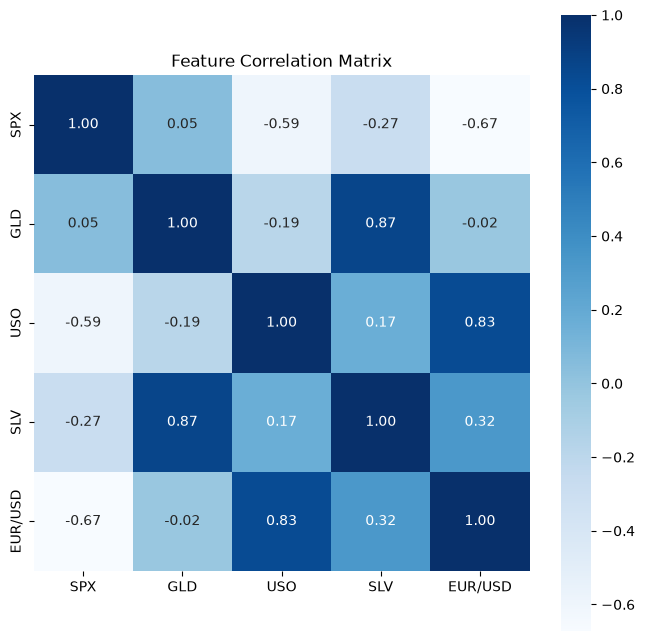

In [12]:
# Correlation matrix
correlation = gold_data.drop(columns=['Date']).corr()
plt.figure(figsize=(8, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    square=True,
    cmap='Blues'
)

plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
print("Correlation with GLD:")
print(correlation['GLD'].sort_values(ascending=False))

Correlation with GLD:
GLD        1.000000
SLV        0.866632
SPX        0.049345
EUR/USD   -0.024375
USO       -0.186360
Name: GLD, dtype: float64


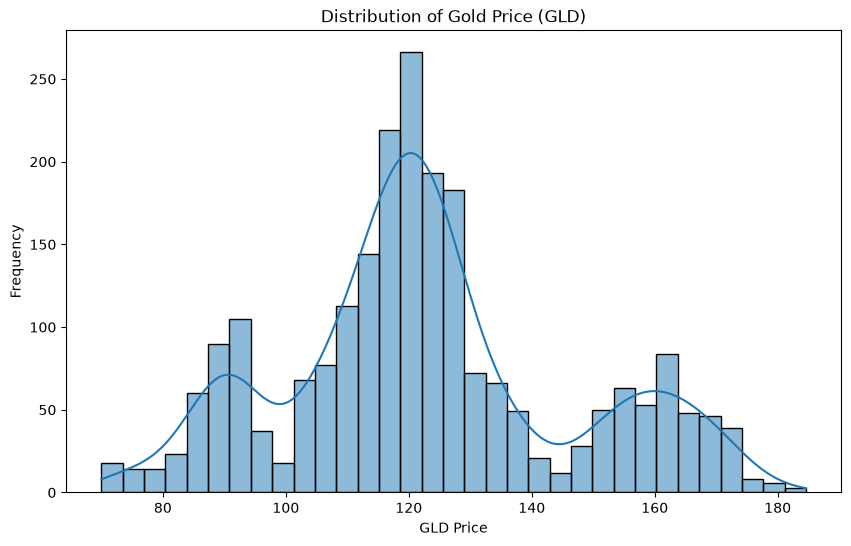

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    gold_data['GLD'],
    kde=True
)

plt.title('Distribution of Gold Price (GLD)')
plt.xlabel('GLD Price')
plt.ylabel('Frequency')

plt.show()

In [15]:
# Features and target for Random Forest
X_rf = gold_data.drop(columns=['Date', 'GLD'])
y_rf = gold_data['GLD']

print("Features:")
print(X_rf.columns.tolist())

print("\nTarget:")
print("GLD")

print("\nFeature shape:", X_rf.shape)
print("Target shape:", y_rf.shape)

Features:
['SPX', 'USO', 'SLV', 'EUR/USD']

Target:
GLD

Feature shape: (2290, 4)
Target shape: (2290,)


In [16]:
# Chronological train-test split
split_index = int(len(gold_data) * 0.80)

X_rf_train = X_rf.iloc[:split_index]
X_rf_test = X_rf.iloc[split_index:]

y_rf_train = y_rf.iloc[:split_index]
y_rf_test = y_rf.iloc[split_index:]

print("Training samples:", len(X_rf_train))
print("Testing samples:", len(X_rf_test))

Training samples: 1832
Testing samples: 458


In [17]:
# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_rf_train, y_rf_train)
print("Random Forest training complete!")

Random Forest training complete!


In [18]:
# Random Forest predictions
rf_predictions = rf_model.predict(X_rf_test)

print("First 10 predictions:")
print(rf_predictions[:10])

First 10 predictions:
[119.10959816 119.36739914 119.47040016 119.51780012 119.44859925
 119.32639862 119.56619978 119.81110021 122.85869934 122.54429967]


In [19]:
# Random Forest evaluation
rf_r2 = r2_score(y_rf_test, rf_predictions)

rf_mae = mean_absolute_error(
    y_rf_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_rf_test,
        rf_predictions
    )
)

rf_mape = np.mean(
    np.abs(
        (y_rf_test - rf_predictions) / y_rf_test
    )
) * 100

rf_pearson, _ = pearsonr(
    y_rf_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print(f"R² Score:          {rf_r2:.4f}")
print(f"MAE:               {rf_mae:.4f}")
print(f"RMSE:              {rf_rmse:.4f}")
print(f"MAPE:              {rf_mape:.2f}%")
print(f"Pearson Correlation: {rf_pearson:.4f}")

Random Forest Results
---------------------
R² Score:          -0.4556
MAE:               4.4947
RMSE:              5.8403
MAPE:              3.71%
Pearson Correlation: -0.0648


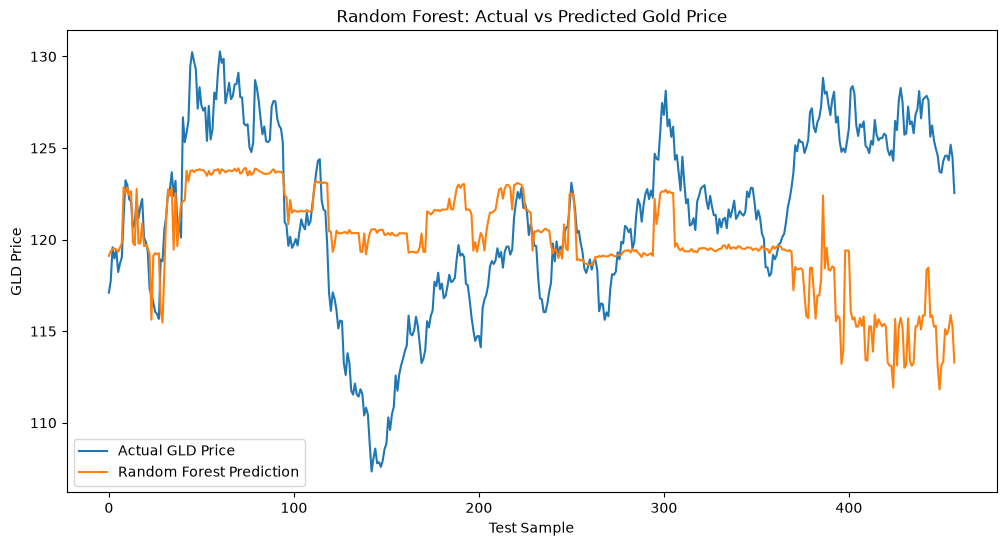

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_rf_test.values,
    label='Actual GLD Price'
)

plt.plot(
    rf_predictions,
    label='Random Forest Prediction'
)

plt.title('Random Forest: Actual vs Predicted Gold Price')
plt.xlabel('Test Sample')
plt.ylabel('GLD Price')
plt.legend()

plt.show()

In [21]:
# Save Random Forest model
joblib.dump(
    rf_model,
    'random_forest_v3.pkl'
)

print("Random Forest V3 saved successfully!")

Random Forest V3 saved successfully!


### LSTM Model

The LSTM model is trained independently from the Random Forest model.
It uses historical sequences of market features to predict the GLD price.

In [22]:
# Select features for LSTM
lstm_features = ['SPX', 'USO', 'SLV', 'EUR/USD', 'GLD']
lstm_data = gold_data[lstm_features].copy()

print(lstm_data.head())
print("\nShape:", lstm_data.shape)

           SPX        USO     SLV   EUR/USD        GLD
0  1447.160034  78.470001  15.180  1.471692  84.860001
1  1447.160034  78.370003  15.285  1.474491  85.570000
2  1411.630005  77.309998  15.167  1.475492  85.129997
3  1416.180054  75.500000  15.053  1.468299  84.769997
4  1390.189941  76.059998  15.590  1.557099  86.779999

Shape: (2290, 5)


In [23]:
# Scale LSTM data
lstm_scaler = MinMaxScaler(feature_range=(0, 1))
lstm_scaled = lstm_scaler.fit_transform(lstm_data)

print("Scaled data shape:", lstm_scaled.shape)
print(lstm_scaled[:5])

Scaled data shape: (2290, 5)
[[0.35087007 0.64380934 0.16480084 0.77292403 0.12967974]
 [0.35087007 0.64289628 0.1675345  0.77792447 0.13587574]
 [0.33469315 0.63321764 0.16446239 0.77971277 0.13203593]
 [0.3367648  0.616691   0.16149441 0.76686241 0.1288943 ]
 [0.32493142 0.6218042  0.17547515 0.92550438 0.14643511]]


In [24]:
# Chronological split for LSTM
lstm_split_index = int(len(lstm_data) * 0.80)

lstm_train_data = lstm_data.iloc[:lstm_split_index]
lstm_test_data = lstm_data.iloc[lstm_split_index:]

print("LSTM training samples:", len(lstm_train_data))
print("LSTM testing samples:", len(lstm_test_data))

LSTM training samples: 1832
LSTM testing samples: 458


In [25]:
# Fit scaler ONLY on training data
lstm_scaler = MinMaxScaler(feature_range=(0, 1))
lstm_train_scaled = lstm_scaler.fit_transform(lstm_train_data)
lstm_test_scaled = lstm_scaler.transform(lstm_test_data)

print("Training scaled shape:", lstm_train_scaled.shape)
print("Testing scaled shape:", lstm_test_scaled.shape)

Training scaled shape: (1832, 5)
Testing scaled shape: (458, 5)


In [26]:
# Fit scaler ONLY on training data
lstm_scaler = MinMaxScaler(feature_range=(0, 1))
lstm_train_scaled = lstm_scaler.fit_transform(lstm_train_data)
lstm_test_scaled = lstm_scaler.transform(lstm_test_data)

print("Training scaled shape:", lstm_train_scaled.shape)
print("Testing scaled shape:", lstm_test_scaled.shape)

Training scaled shape: (1832, 5)
Testing scaled shape: (458, 5)


In [27]:
# Create sequences for LSTM
lookback = 30

X_lstm_train = []
y_lstm_train = []

for i in range(lookback, len(lstm_train_scaled)):
    X_lstm_train.append(
        lstm_train_scaled[i-lookback:i]
    )
    y_lstm_train.append(
        lstm_train_scaled[i, 4]   # GLD column
    )

X_lstm_train = np.array(X_lstm_train)
y_lstm_train = np.array(y_lstm_train)

print("X training shape:", X_lstm_train.shape)
print("y training shape:", y_lstm_train.shape)

X training shape: (1802, 30, 5)
y training shape: (1802,)


In [28]:
# Combine the last lookback observations from training
# with the test data to create test sequences
lstm_test_with_context = np.concatenate(
    [
        lstm_train_scaled[-lookback:],
        lstm_test_scaled
    ],
    axis=0
)

X_lstm_test = []
y_lstm_test = []

for i in range(lookback, len(lstm_test_with_context)):
    X_lstm_test.append(
        lstm_test_with_context[i-lookback:i]
    )
    y_lstm_test.append(
        lstm_test_with_context[i, 4]   # GLD
    )

X_lstm_test = np.array(X_lstm_test)
y_lstm_test = np.array(y_lstm_test)

print("X test shape:", X_lstm_test.shape)
print("y test shape:", y_lstm_test.shape)

X test shape: (458, 30, 5)
y test shape: (458,)


In [29]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])
    ),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.summary()

E0000 00:00:1791014892.173017   18436 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:50

/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM
history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0230 - val_loss: 0.0024
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0292 - val_loss: 0.0022
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0111 - val_loss: 0.0021
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0155 - val_loss: 0.0022
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0279 - val_loss: 0.0037
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0309 - val_loss: 0.0024
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0333 - val_loss: 0.0013
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0214 - val_loss: 0.0010
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0116 - val_loss: 7.7474e-04
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0092 - val_loss: 0.0116
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0111 - val_loss: 0.0034
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss:

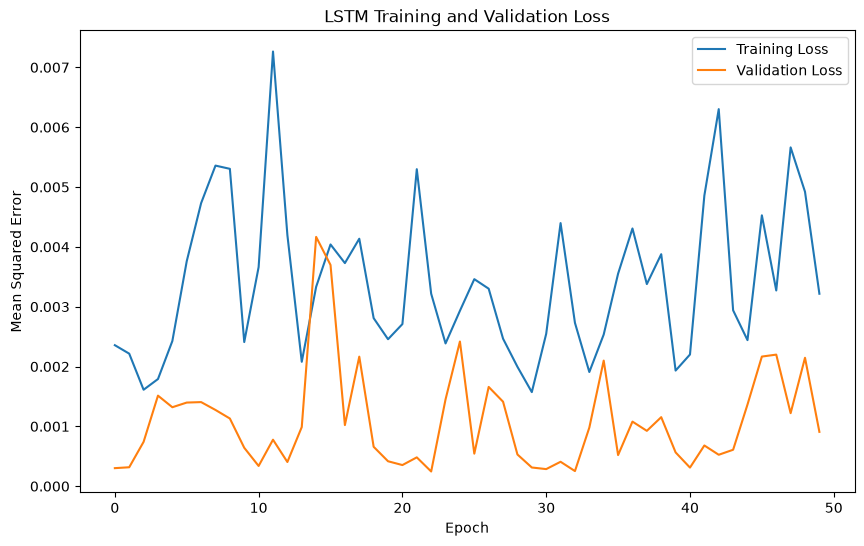

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.show()

In [38]:
# Make predictions
lstm_predictions_scaled = lstm_model.predict(X_lstm_test)
print("Prediction shape:", lstm_predictions_scaled.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Prediction shape: (458, 1)


In [39]:
# Convert scaled predictions back to original GLD prices
dummy_pred = np.zeros((len(lstm_predictions_scaled), 5))
dummy_pred[:, 4] = lstm_predictions_scaled.flatten()

lstm_predictions = lstm_scaler.inverse_transform(dummy_pred)[:, 4]

# Convert actual scaled GLD values back as well
dummy_actual = np.zeros((len(y_lstm_test), 5))
dummy_actual[:, 4] = y_lstm_test

lstm_actual = lstm_scaler.inverse_transform(dummy_actual)[:, 4]

print("First 10 actual values:")
print(lstm_actual[:10])

print("\nFirst 10 predicted values:")
print(lstm_predictions[:10])

First 10 actual values:
[117.110001 117.739998 119.580002 118.970001 119.419998 118.230003
 118.699997 119.040001 121.290001 123.239998]

First 10 predicted values:
[122.74557009 122.52706507 122.28763947 122.48651138 122.66412461
 122.90021029 122.92241835 122.9557902  123.0489049  123.62248611]


In [40]:
# LSTM Evaluation Metrics
lstm_r2 = r2_score(
    lstm_actual,
    lstm_predictions
)

lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_predictions
    )
)

lstm_mape = np.mean(
    np.abs(
        (lstm_actual - lstm_predictions) / lstm_actual
    )
) * 100

lstm_pearson, _ = pearsonr(
    lstm_actual,
    lstm_predictions
)

print("LSTM Results")
print("---------------------")
print(f"R² Score:             {lstm_r2:.4f}")
print(f"MAE:                  {lstm_mae:.4f}")
print(f"RMSE:                 {lstm_rmse:.4f}")
print(f"MAPE:                 {lstm_mape:.2f}%")
print(f"Pearson Correlation:  {lstm_pearson:.4f}")

LSTM Results
---------------------
R² Score:             0.2936
MAE:                  3.4585
RMSE:                 4.0685
MAPE:                 2.83%
Pearson Correlation:  0.7489


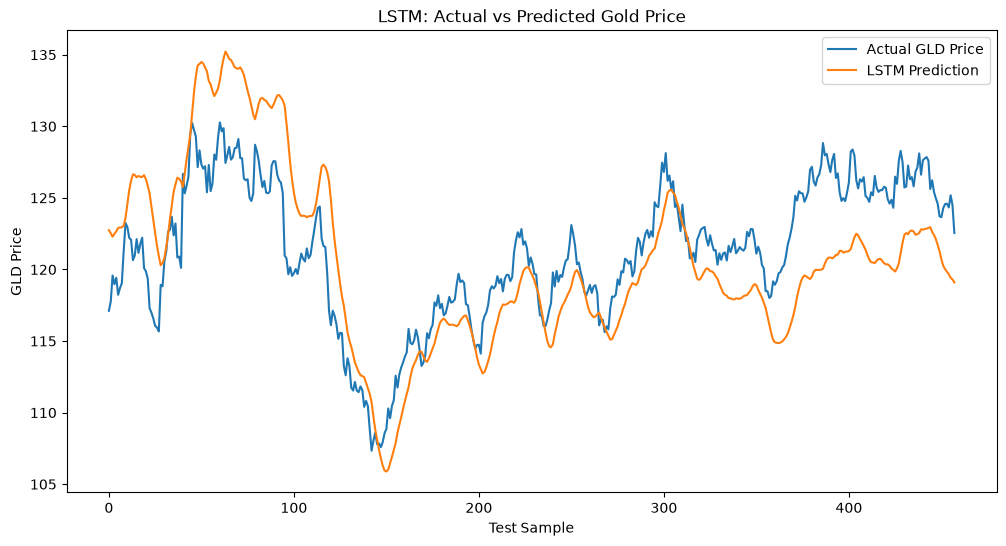

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(
    lstm_actual,
    label='Actual GLD Price'
)

plt.plot(
    lstm_predictions,
    label='LSTM Prediction'
)

plt.title('LSTM: Actual vs Predicted Gold Price')
plt.xlabel('Test Sample')
plt.ylabel('GLD Price')
plt.legend()

plt.show()

### Hybrid Neural Network

The Random Forest and LSTM models are independently trained.
Their predictions are combined as inputs to a neural-network meta-model.

In [43]:
# Verify prediction alignment
print("RF predictions:", len(rf_predictions))
print("LSTM predictions:", len(lstm_predictions))
print("LSTM actual:", len(lstm_actual))

RF predictions: 458
LSTM predictions: 458
LSTM actual: 458


In [44]:
# Create a dataframe containing the base-model predictions
hybrid_data = pd.DataFrame({
    'RF_Prediction': rf_predictions,
    'LSTM_Prediction': lstm_predictions,
    'Actual_GLD': lstm_actual
})

print(hybrid_data.head())
print("\nShape:", hybrid_data.shape)

   RF_Prediction  LSTM_Prediction  Actual_GLD
0     119.109598       122.745570  117.110001
1     119.367399       122.527065  117.739998
2     119.470400       122.287639  119.580002
3     119.517800       122.486511  118.970001
4     119.448599       122.664125  119.419998

Shape: (458, 3)


#### Hybrid Model Data Preparation

The hybrid model uses a three-way chronological split.

- Base-model training data: 70%
- Meta-model training data: 10%
- Final test data: 20%

The final test set remains completely unseen during meta-model training.

In [45]:
# Define chronological split points
total_length = len(gold_data)

base_train_end = int(total_length * 0.70)
meta_train_end = int(total_length * 0.80)

print("Total observations:", total_length)
print("Base-model training:", base_train_end)
print("Meta-model training:", meta_train_end - base_train_end)
print("Final test:", total_length - meta_train_end)

Total observations: 2290
Base-model training: 1603
Meta-model training: 229
Final test: 458


#### Hybrid Random Forest Predictions

A new Random Forest is trained only on the first 70% of the chronological data.
Its predictions on the following 10% are used to train the meta-model.
Its predictions on the final 20% are reserved for final hybrid evaluation.

In [46]:
# Prepare Random Forest data for the hybrid model
rf_features = ['SPX', 'USO', 'SLV', 'EUR/USD']
rf_target = 'GLD'

X_hybrid_rf = gold_data[rf_features]
y_hybrid_rf = gold_data[rf_target]

# Three chronological regions
X_rf_base_train = X_hybrid_rf.iloc[:base_train_end]
y_rf_base_train = y_hybrid_rf.iloc[:base_train_end]

X_rf_meta_train = X_hybrid_rf.iloc[base_train_end:meta_train_end]
y_rf_meta_train = y_hybrid_rf.iloc[base_train_end:meta_train_end]

X_rf_final_test = X_hybrid_rf.iloc[meta_train_end:]
y_rf_final_test = y_hybrid_rf.iloc[meta_train_end:]

print("RF base training:", X_rf_base_train.shape)
print("RF meta training:", X_rf_meta_train.shape)
print("RF final test:", X_rf_final_test.shape)

RF base training: (1603, 4)
RF meta training: (229, 4)
RF final test: (458, 4)


In [47]:
# Train Random Forest for the hybrid pipeline
hybrid_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

hybrid_rf_model.fit(
    X_rf_base_train,
    y_rf_base_train
)

print("Hybrid RF training complete.")

Hybrid RF training complete.


In [48]:
# Generate RF predictions for meta-training and final test
rf_meta_predictions = hybrid_rf_model.predict(
    X_rf_meta_train
)

rf_final_predictions = hybrid_rf_model.predict(
    X_rf_final_test
)

print("RF meta predictions:", rf_meta_predictions.shape)
print("RF final predictions:", rf_final_predictions.shape)

RF meta predictions: (229,)
RF final predictions: (458,)


#### Hybrid LSTM Predictions

The LSTM is independently trained on the first 70% of the chronological data.
Its predictions on the next 10% are used to train the meta-model.
The final 20% remains completely unseen for hybrid evaluation.

In [49]:
# Prepare LSTM data for the hybrid pipeline
lstm_features = ['SPX', 'USO', 'SLV', 'EUR/USD', 'GLD']

lstm_hybrid_data = gold_data[lstm_features].copy()

# Chronological regions
lstm_base_train = lstm_hybrid_data.iloc[:base_train_end]
lstm_meta_train = lstm_hybrid_data.iloc[base_train_end:meta_train_end]
lstm_final_test = lstm_hybrid_data.iloc[meta_train_end:]

print("LSTM base training:", lstm_base_train.shape)
print("LSTM meta training:", lstm_meta_train.shape)
print("LSTM final test:", lstm_final_test.shape)

LSTM base training: (1603, 5)
LSTM meta training: (229, 5)
LSTM final test: (458, 5)


In [50]:
# Fit scaler only on base-model training data
hybrid_lstm_scaler = MinMaxScaler(feature_range=(0, 1))

lstm_base_scaled = hybrid_lstm_scaler.fit_transform(
    lstm_base_train
)

lstm_meta_scaled = hybrid_lstm_scaler.transform(
    lstm_meta_train
)

lstm_final_scaled = hybrid_lstm_scaler.transform(
    lstm_final_test
)

print("Base scaled:", lstm_base_scaled.shape)
print("Meta scaled:", lstm_meta_scaled.shape)
print("Final scaled:", lstm_final_scaled.shape)

Base scaled: (1603, 5)
Meta scaled: (229, 5)
Final scaled: (458, 5)


In [51]:
# Create LSTM base-training sequences
X_hybrid_lstm_train = []
y_hybrid_lstm_train = []

for i in range(lookback, len(lstm_base_scaled)):
    X_hybrid_lstm_train.append(
        lstm_base_scaled[i-lookback:i]
    )
    
    y_hybrid_lstm_train.append(
        lstm_base_scaled[i, 4]
    )

X_hybrid_lstm_train = np.array(X_hybrid_lstm_train)
y_hybrid_lstm_train = np.array(y_hybrid_lstm_train)

print("LSTM base X:", X_hybrid_lstm_train.shape)
print("LSTM base y:", y_hybrid_lstm_train.shape)

LSTM base X: (1573, 30, 5)
LSTM base y: (1573,)


In [52]:
# Create LSTM meta-training sequences
lstm_meta_with_context = np.concatenate(
    [
        lstm_base_scaled[-lookback:],
        lstm_meta_scaled
    ],
    axis=0
)

X_hybrid_lstm_meta = []
y_hybrid_lstm_meta = []

for i in range(lookback, len(lstm_meta_with_context)):
    X_hybrid_lstm_meta.append(
        lstm_meta_with_context[i-lookback:i]
    )
    
    y_hybrid_lstm_meta.append(
        lstm_meta_with_context[i, 4]
    )

X_hybrid_lstm_meta = np.array(X_hybrid_lstm_meta)
y_hybrid_lstm_meta = np.array(y_hybrid_lstm_meta)

print("LSTM meta X:", X_hybrid_lstm_meta.shape)
print("LSTM meta y:", y_hybrid_lstm_meta.shape)

LSTM meta X: (229, 30, 5)
LSTM meta y: (229,)


In [53]:
# Create LSTM final-test sequences
lstm_final_with_context = np.concatenate(
    [
        lstm_meta_scaled[-lookback:],
        lstm_final_scaled
    ],
    axis=0
)

X_hybrid_lstm_final = []
y_hybrid_lstm_final = []

for i in range(lookback, len(lstm_final_with_context)):
    X_hybrid_lstm_final.append(
        lstm_final_with_context[i-lookback:i]
    )
    
    y_hybrid_lstm_final.append(
        lstm_final_with_context[i, 4]
    )

X_hybrid_lstm_final = np.array(X_hybrid_lstm_final)
y_hybrid_lstm_final = np.array(y_hybrid_lstm_final)

print("LSTM final X:", X_hybrid_lstm_final.shape)
print("LSTM final y:", y_hybrid_lstm_final.shape)

LSTM final X: (458, 30, 5)
LSTM final y: (458,)


#### Hybrid LSTM Model

This LSTM is trained independently from the Random Forest.
Its out-of-sample predictions are later provided to the meta neural network.

In [54]:
# Build LSTM for hybrid pipeline
hybrid_lstm_model = Sequential([
    LSTM(64, return_sequences=True,
        input_shape=(
            X_hybrid_lstm_train.shape[1],
            X_hybrid_lstm_train.shape[2]
        )
    ),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

hybrid_lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

hybrid_lstm_model.summary()

/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Train hybrid LSTM
hybrid_history = hybrid_lstm_model.fit(
    X_hybrid_lstm_train,
    y_hybrid_lstm_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

Epoch 1/50


45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0184 - val_loss: 0.0159
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0376 - val_loss: 0.0074
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0321 - val_loss: 0.0053
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0505 - val_loss: 8.8703e-04
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0551 - val_loss: 0.0018
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0486 - val_loss: 0.0352
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0544 - val_loss: 0.0248
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0234 - val_loss: 0.0019
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0092 - val_loss: 0.0022
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0119 - val_loss: 0.0271
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0168 - val_loss: 0.0144
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0120 - v

In [57]:
# Generate LSTM predictions for meta-training data
lstm_meta_predictions_scaled = hybrid_lstm_model.predict(
    X_hybrid_lstm_meta
)
print(
    "Scaled LSTM meta predictions:",
    lstm_meta_predictions_scaled.shape
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Scaled LSTM meta predictions: (229, 1)


In [58]:
# Convert meta predictions back to original GLD prices
dummy_meta_pred = np.zeros(
    (len(lstm_meta_predictions_scaled), 5)
)
dummy_meta_pred[:, 4] = (
    lstm_meta_predictions_scaled.flatten()
)
lstm_meta_predictions = (
    hybrid_lstm_scaler
    .inverse_transform(dummy_meta_pred)[:, 4]
)
print(
    "LSTM meta predictions:",
    lstm_meta_predictions.shape
)

LSTM meta predictions: (229,)


In [59]:
# Generate LSTM predictions for final test data
lstm_final_predictions_scaled = hybrid_lstm_model.predict(
    X_hybrid_lstm_final
)
print(
    "Scaled LSTM final predictions:",
    lstm_final_predictions_scaled.shape
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Scaled LSTM final predictions: (458, 1)


In [60]:
# Convert final predictions back to original GLD prices
dummy_final_pred = np.zeros(
    (len(lstm_final_predictions_scaled), 5)
)
dummy_final_pred[:, 4] = (
    lstm_final_predictions_scaled.flatten()
)
lstm_final_predictions = (
    hybrid_lstm_scaler
    .inverse_transform(dummy_final_pred)[:, 4]
)
print(
    "LSTM final predictions:",
    lstm_final_predictions.shape
)

LSTM final predictions: (458,)


In [61]:
# Actual GLD values for meta-training period
dummy_meta_actual = np.zeros(
    (len(y_hybrid_lstm_meta), 5)
)

dummy_meta_actual[:, 4] = y_hybrid_lstm_meta

lstm_meta_actual = (
    hybrid_lstm_scaler
    .inverse_transform(dummy_meta_actual)[:, 4]
)

In [62]:
# Actual GLD values for final test period
dummy_final_actual = np.zeros(
    (len(y_hybrid_lstm_final), 5)
)

dummy_final_actual[:, 4] = y_hybrid_lstm_final

lstm_final_actual = (
    hybrid_lstm_scaler
    .inverse_transform(dummy_final_actual)[:, 4]
)

print("Meta actual:", lstm_meta_actual.shape)
print("Final actual:", lstm_final_actual.shape)

Meta actual: (229,)
Final actual: (458,)


#### Meta Neural Network

The meta-model receives the independently generated Random Forest and LSTM predictions as input features.

It learns how to combine these predictions to produce the final GLD prediction.

In [63]:
# Create meta-model training data
X_meta_train = np.column_stack([
    rf_meta_predictions,
    lstm_meta_predictions
])

y_meta_train = lstm_meta_actual

# Create final test data
X_meta_test = np.column_stack([
    rf_final_predictions,
    lstm_final_predictions
])

y_meta_test = lstm_final_actual

print("Meta training X:", X_meta_train.shape)
print("Meta training y:", y_meta_train.shape)

print("Meta test X:", X_meta_test.shape)
print("Meta test y:", y_meta_test.shape)

Meta training X: (229, 2)
Meta training y: (229,)
Meta test X: (458, 2)
Meta test y: (458,)


In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
# Scale meta-model inputs
meta_scaler = StandardScaler()

X_meta_train_scaled = meta_scaler.fit_transform(
    X_meta_train
)

X_meta_test_scaled = meta_scaler.transform(
    X_meta_test
)

print("Scaled meta-training shape:", X_meta_train_scaled.shape)
print("Scaled meta-test shape:", X_meta_test_scaled.shape)

Scaled meta-training shape: (229, 2)
Scaled meta-test shape: (458, 2)


In [66]:
# Build meta neural network
meta_model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1)
])

meta_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

meta_model.summary()

/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/layers/core/dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Train meta neural network
meta_history = meta_model.fit(
    X_meta_train_scaled,
    y_meta_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6120

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.8548 - val_loss: 17.4019
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8253 - val_loss: 17.6755
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.7921 - val_loss: 17.9756
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7613 - val_loss: 17.8067
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7206 - val_loss: 17.6232
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6848 - val_loss: 17.5676
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6497 - val_loss: 17.5611
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6149 - val_loss: 17.5539
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5810 - val_loss: 17.5396
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5482 - val_loss: 17.5196
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5162 - val_loss: 17.4946
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.48

In [74]:
# Train meta neural network

meta_history = meta_model.fit(
    X_meta_train_scaled,
    y_meta_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.3284 - val_loss: 25.8496
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.3263 - val_loss: 25.9465
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.3242 - val_loss: 26.0439
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.3223 - val_loss: 26.1484
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.3203 - val_loss: 26.2519
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.3185 - val_loss: 26.3525
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3167 - val_loss: 26.4528
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3149 - val_loss: 26.5536
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3132 - val_loss: 26.6545
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3116 - val_loss: 26.7550
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3100 - val_loss: 26.8550
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

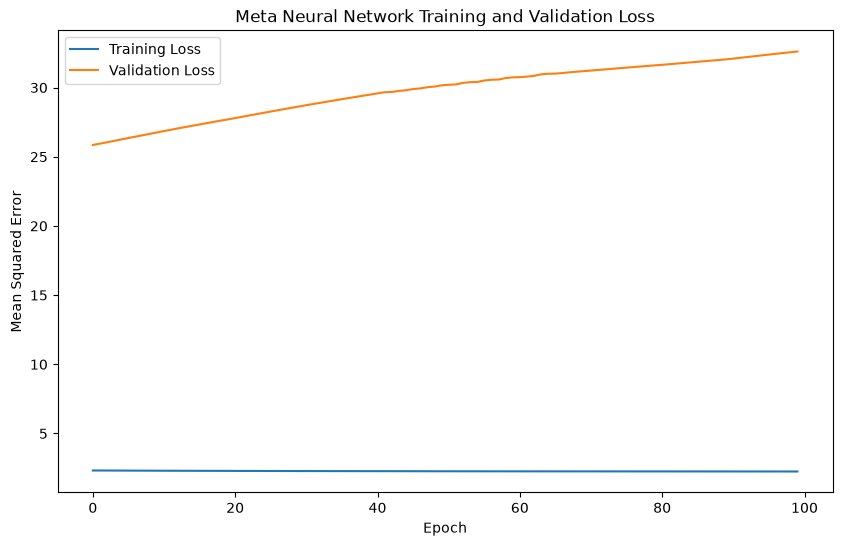

In [75]:
plt.figure(figsize=(10, 6))

plt.plot(
    meta_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    meta_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Meta Neural Network Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.show()

In [76]:
# Generate final hybrid predictions

hybrid_predictions = meta_model.predict(
    X_meta_test_scaled
)

hybrid_predictions = hybrid_predictions.flatten()

print("Hybrid prediction shape:", hybrid_predictions.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Hybrid prediction shape: (458,)


In [78]:
from scipy.stats import spearmanr

In [79]:
# Calculate Hybrid metrics
hybrid_mae = mean_absolute_error(
    y_meta_test,
    hybrid_predictions
)

hybrid_rmse = np.sqrt(
    mean_squared_error(
        y_meta_test,
        hybrid_predictions
    )
)

hybrid_r2 = r2_score(
    y_meta_test,
    hybrid_predictions
)

hybrid_mape = np.mean(
    np.abs(
        (y_meta_test - hybrid_predictions)
        / y_meta_test
    )
) * 100

hybrid_pearson, _ = pearsonr(
    y_meta_test,
    hybrid_predictions
)

hybrid_spearman, _ = spearmanr(
    y_meta_test,
    hybrid_predictions
)

print("Hybrid V3 Results")
print("-----------------")
print(f"R² Score:          {hybrid_r2:.4f}")
print(f"MAE:               {hybrid_mae:.4f}")
print(f"RMSE:              {hybrid_rmse:.4f}")
print(f"MAPE:              {hybrid_mape:.2f}%")
print(f"Pearson:           {hybrid_pearson:.4f}")
print(f"Spearman:          {hybrid_spearman:.4f}")

Hybrid V3 Results
-----------------
R² Score:          -18.2375
MAE:               13.9324
RMSE:              21.2320
MAPE:              11.26%
Pearson:           0.4658
Spearman:          0.4895


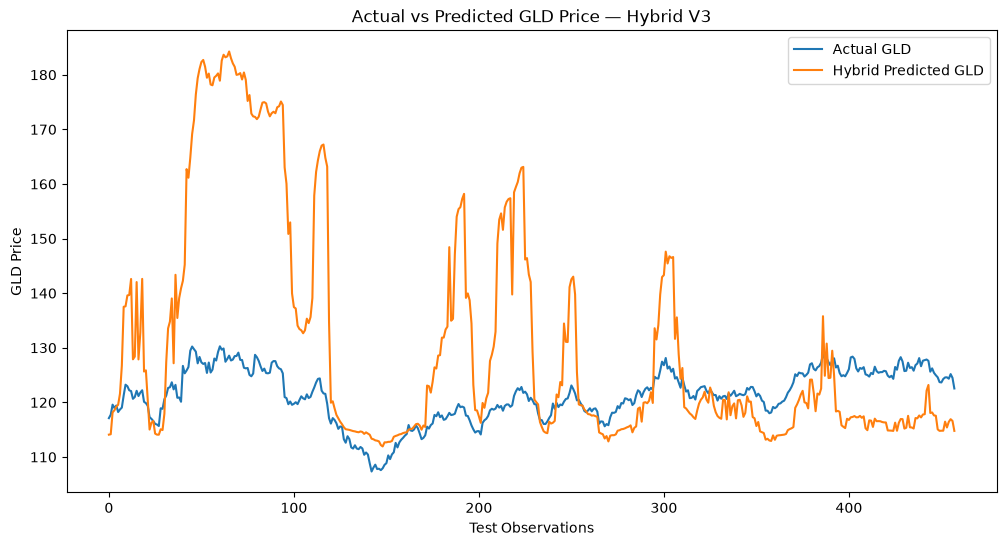

In [80]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_meta_test,
    label='Actual GLD'
)

plt.plot(
    hybrid_predictions,
    label='Hybrid Predicted GLD'
)

plt.title('Actual vs Predicted GLD Price — Hybrid V3')
plt.xlabel('Test Observations')
plt.ylabel('GLD Price')
plt.legend()

plt.show()

In [81]:
print("Actual range:")
print(y_meta_test.min(), y_meta_test.max())

print("\nRF prediction range:")
print(rf_final_predictions.min(), rf_final_predictions.max())

print("\nLSTM prediction range:")
print(lstm_final_predictions.min(), lstm_final_predictions.max())

print("\nHybrid prediction range:")
print(hybrid_predictions.min(), hybrid_predictions.max())

Actual range:
107.339996 130.270004

RF prediction range:
110.46189874000007 124.05630119

LSTM prediction range:
124.59047463920439 140.94739004314758

Hybrid prediction range:
111.92718 184.2631


In [82]:
print("First 10 actual:")
print(y_meta_test[:10])

print("\nFirst 10 RF:")
print(rf_final_predictions[:10])

print("\nFirst 10 LSTM:")
print(lstm_final_predictions[:10])

print("\nFirst 10 Hybrid:")
print(hybrid_predictions[:10])

First 10 actual:
[117.110001 117.739998 119.580002 118.970001 119.419998 118.230003
 118.699997 119.040001 121.290001 123.239998]

First 10 RF:
[112.8593013  112.934401   117.24890056 117.29950031 117.5119006
 117.43850047 117.85200042 118.83550061 121.05350016 120.84530022]

First 10 LSTM:
[128.3436363  128.48402209 128.56983542 128.82414721 129.09238557
 129.3978343  129.60755923 129.77176839 129.90669011 130.2371848 ]

First 10 Hybrid:
[114.08848  114.162025 118.160995 118.55964  119.20593  119.55554
 121.59498  126.71507  137.50754  137.59415 ]


In [84]:
print("========== META TRAIN ==========")

print("Actual:")
print(y_meta_train.min(), y_meta_train.max())

print("\nRF:")
print(rf_meta_predictions.min(), rf_meta_predictions.max())

print("\nLSTM:")
print(lstm_meta_predictions.min(), lstm_meta_predictions.max())


print("\n========== FINAL TEST ==========")

print("Actual:")
print(y_meta_test.min(), y_meta_test.max())

print("\nRF:")
print(rf_final_predictions.min(), rf_final_predictions.max())

print("\nLSTM:")
print(lstm_final_predictions.min(), lstm_final_predictions.max())

========== META TRAIN ==========
Actual:
100.5 121.5

RF:
108.78919911000001 119.99660066000003

LSTM:
116.87888644222582 130.96359282714604

========== FINAL TEST ==========
Actual:
107.339996 130.270004

RF:
110.46189874000007 124.05630119

LSTM:
124.59047463920439 140.94739004314758


In [85]:
simple_hybrid_predictions = (
    rf_final_predictions + lstm_final_predictions
) / 2

simple_hybrid_mae = mean_absolute_error(
    y_meta_test, simple_hybrid_predictions
)

simple_hybrid_rmse = np.sqrt(
    mean_squared_error(y_meta_test, simple_hybrid_predictions)
)

simple_hybrid_r2 = r2_score(
    y_meta_test, simple_hybrid_predictions
)

simple_hybrid_mape = np.mean(
    np.abs(
        (y_meta_test - simple_hybrid_predictions)
        / y_meta_test
    )
) * 100

simple_hybrid_pearson, _ = pearsonr(
    y_meta_test, simple_hybrid_predictions
)

simple_hybrid_spearman, _ = spearmanr(
    y_meta_test, simple_hybrid_predictions
)

print("Simple Average Hybrid Results")
print("-----------------------------")
print(f"R² Score:          {simple_hybrid_r2:.4f}")
print(f"MAE:               {simple_hybrid_mae:.4f}")
print(f"RMSE:              {simple_hybrid_rmse:.4f}")
print(f"MAPE:              {simple_hybrid_mape:.2f}%")
print(f"Pearson:           {simple_hybrid_pearson:.4f}")
print(f"Spearman:          {simple_hybrid_spearman:.4f}")

Simple Average Hybrid Results
-----------------------------
R² Score:          -0.1224
MAE:               4.3590
RMSE:              5.1286
MAPE:              3.66%
Pearson:           0.5559
Spearman:          0.4868


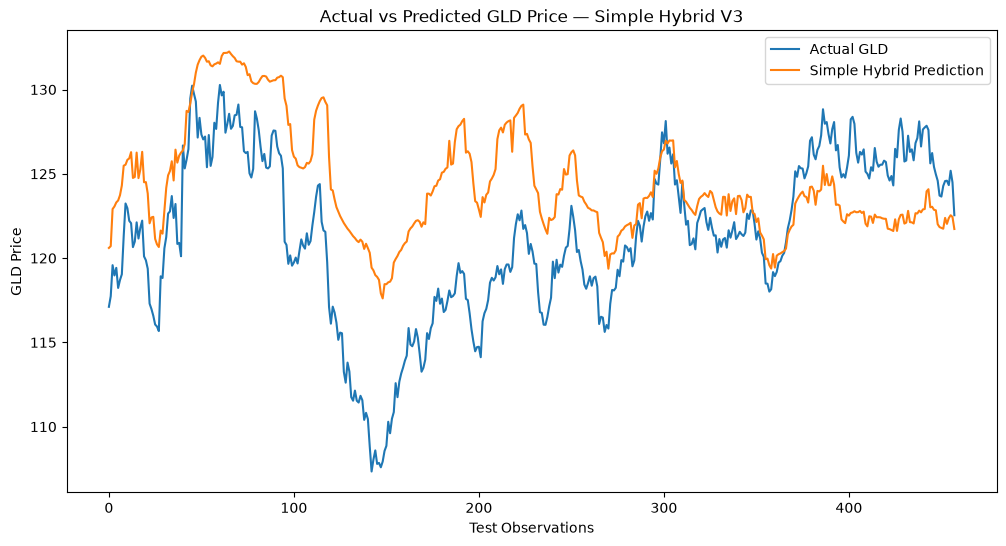

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_meta_test,
    label='Actual GLD'
)

plt.plot(
    simple_hybrid_predictions,
    label='Simple Hybrid Prediction'
)

plt.title('Actual vs Predicted GLD Price — Simple Hybrid V3')
plt.xlabel('Test Observations')
plt.ylabel('GLD Price')
plt.legend()
plt.show()

In [87]:
from sklearn.linear_model import LinearRegression
linear_meta_model = LinearRegression()

linear_meta_model.fit(
    X_meta_train,
    y_meta_train
)

linear_hybrid_predictions = linear_meta_model.predict(
    X_meta_test
)

print("Meta-model coefficients:")
print("RF weight:", linear_meta_model.coef_[0])
print("LSTM weight:", linear_meta_model.coef_[1])
print("Bias:", linear_meta_model.intercept_)

Meta-model coefficients:
RF weight: 0.1599951129438435
LSTM weight: 1.256053061876199
Bias: -61.627320294405706


In [88]:
linear_hybrid_mae = mean_absolute_error(
    y_meta_test, linear_hybrid_predictions
)

linear_hybrid_rmse = np.sqrt(
    mean_squared_error(y_meta_test, linear_hybrid_predictions)
)

linear_hybrid_r2 = r2_score(
    y_meta_test, linear_hybrid_predictions
)

linear_hybrid_mape = np.mean(
    np.abs(
        (y_meta_test - linear_hybrid_predictions)
        / y_meta_test
    )
) * 100

linear_hybrid_pearson, _ = pearsonr(
    y_meta_test, linear_hybrid_predictions
)

linear_hybrid_spearman, _ = spearmanr(
    y_meta_test, linear_hybrid_predictions
)

print("\nLinear Hybrid V3 Results")
print("-----------------------")
print(f"R² Score:          {linear_hybrid_r2:.4f}")
print(f"MAE:               {linear_hybrid_mae:.4f}")
print(f"RMSE:              {linear_hybrid_rmse:.4f}")
print(f"MAPE:              {linear_hybrid_mape:.2f}%")
print(f"Pearson:           {linear_hybrid_pearson:.4f}")
print(f"Spearman:          {linear_hybrid_spearman:.4f}")


Linear Hybrid V3 Results
-----------------------
R² Score:          0.1329
MAE:               3.9303
RMSE:              4.5078
MAPE:              3.25%
Pearson:           0.5726
Spearman:          0.4761


In [89]:
simple_hybrid_predictions = (
    rf_final_predictions + lstm_final_predictions
) / 2

simple_hybrid_mae = mean_absolute_error(
    y_meta_test, simple_hybrid_predictions
)

simple_hybrid_rmse = np.sqrt(
    mean_squared_error(y_meta_test, simple_hybrid_predictions)
)

simple_hybrid_r2 = r2_score(
    y_meta_test, simple_hybrid_predictions
)

simple_hybrid_mape = np.mean(
    np.abs(
        (y_meta_test - simple_hybrid_predictions)
        / y_meta_test
    )
) * 100

simple_hybrid_pearson, _ = pearsonr(
    y_meta_test, simple_hybrid_predictions
)

simple_hybrid_spearman, _ = spearmanr(
    y_meta_test, simple_hybrid_predictions
)

print("Simple Average Hybrid V3 Results")
print("--------------------------------")
print(f"R² Score:          {simple_hybrid_r2:.4f}")
print(f"MAE:               {simple_hybrid_mae:.4f}")
print(f"RMSE:              {simple_hybrid_rmse:.4f}")
print(f"MAPE:              {simple_hybrid_mape:.2f}%")
print(f"Pearson:           {simple_hybrid_pearson:.4f}")
print(f"Spearman:          {simple_hybrid_spearman:.4f}")

Simple Average Hybrid V3 Results
--------------------------------
R² Score:          -0.1224
MAE:               4.3590
RMSE:              5.1286
MAPE:              3.66%
Pearson:           0.5559
Spearman:          0.4868


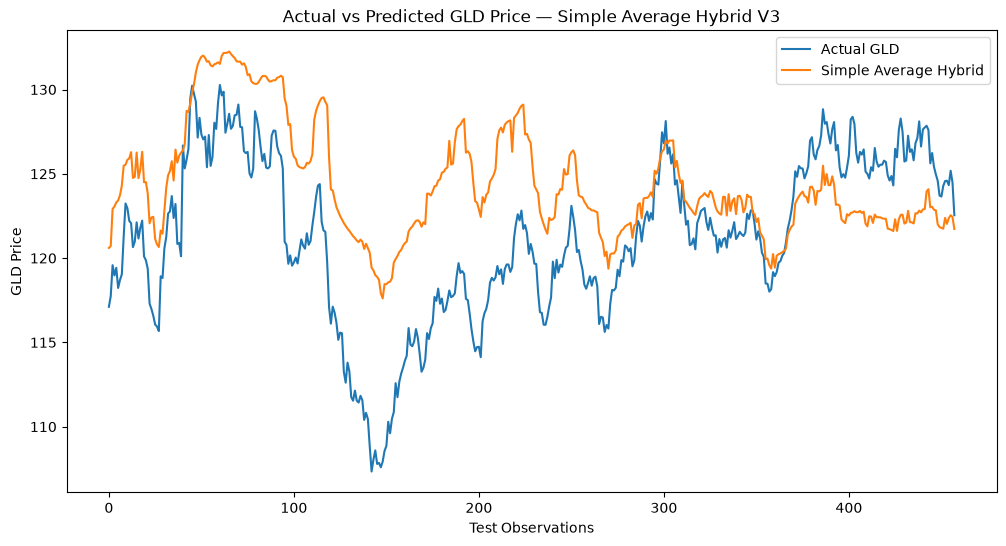

In [90]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_meta_test,
    label='Actual GLD'
)

plt.plot(
    simple_hybrid_predictions,
    label='Simple Average Hybrid'
)

plt.title('Actual vs Predicted GLD Price — Simple Average Hybrid V3')
plt.xlabel('Test Observations')
plt.ylabel('GLD Price')
plt.legend()
plt.show()